## Zadanie 1

In [1]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split


wine = load_wine()

X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.2)


knn = KNeighborsClassifier(n_neighbors=5)
knn = knn.fit(X_train, y_train)

results = knn.score(X_test, y_test)
results

0.6388888888888888

In [89]:
import numpy as np
import matplotlib.pyplot as plt

wine = load_wine()


X_train, X_test, y_train, y_test = train_test_split(
wine.data, wine.target, test_size=0.2)

def bootstrap_knn(X_tr, y_tr, X_te, y_te, n_bootstrap=100):
    X_tr = np.array(X_tr)
    y_tr = np.array(y_tr)
    X_te = np.array(X_te)
    y_te = np.array(y_te)

    accuracy = []
    n_samples = X_tr.shape[0]

    for _ in range(n_bootstrap):
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        X_boot = X_tr[indices]
        y_boot = y_tr[indices]

        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(X_boot, y_boot)

        accuracy.append(knn.score(X_te, y_te))

    return np.array(accuracy)

In [90]:
acc_full = bootstrap_knn(X_train, y_train, X_test, y_test, n_bootstrap=1000)

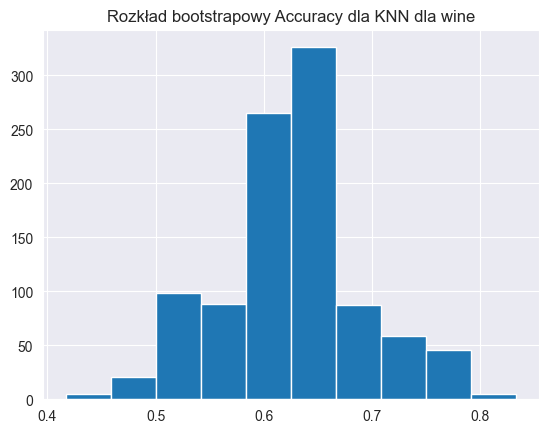

In [91]:
plt.hist(accuracy, )
plt.title("Rozkład bootstrapowy Accuracy dla KNN dla wine")
plt.show()

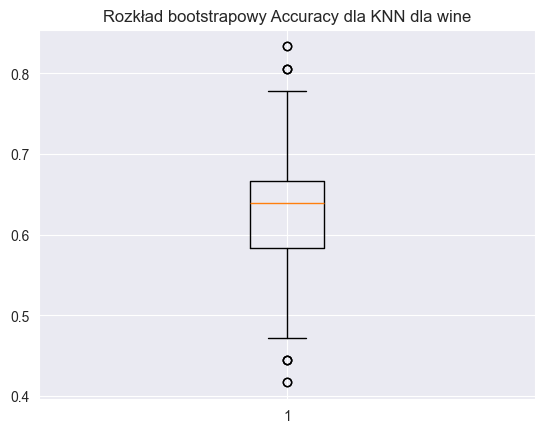

In [92]:
plt.boxplot(accuracy)
plt.title("Rozkład bootstrapowy Accuracy dla KNN dla wine")
plt.show()

In [93]:
lower = np.percentile(accuracy, 2.5)
upper = np.percentile(accuracy, 97.5)
print(lower, upper)

0.4722222222222222 0.75


## Zadanie 2

In [65]:
import pandas as pd
import seaborn as sns
df = pd.DataFrame(wine.data, columns=wine.feature_names)

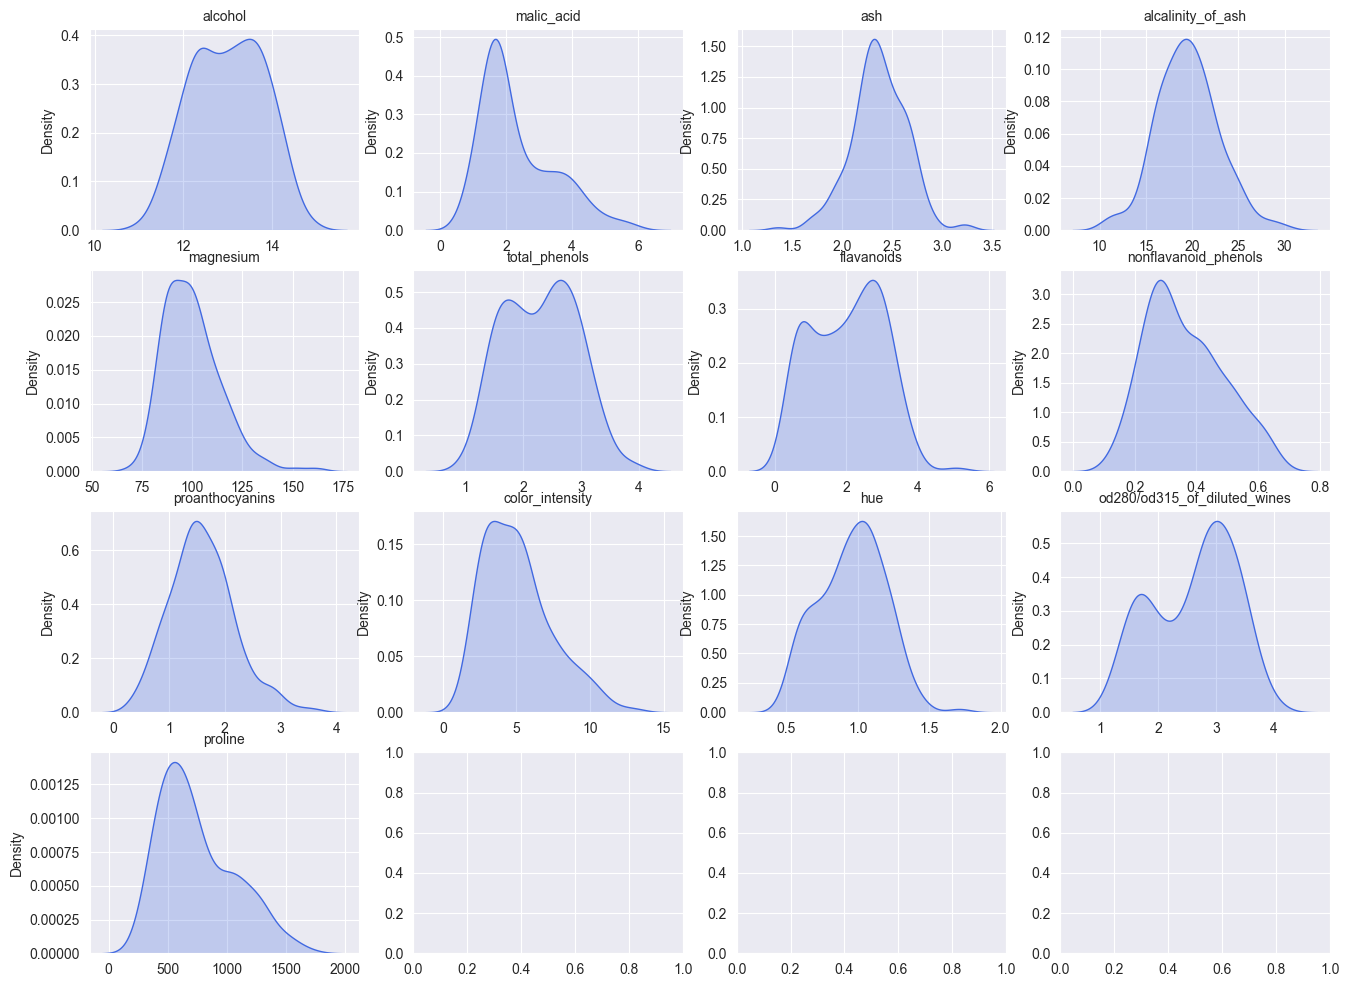

In [67]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i,col in enumerate(df.columns):
    sns.kdeplot(data=df, x=col, fill=True, ax=axes[i], color="royalblue")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")


In [68]:
relevant_features = ['malic_acid','ash','alcalinity_of_ash','magnesium','nonflavanoid_phenols','proanthocyanins','color_intensity','hue','proline']
non_normal_features = [col for col in df.columns if col not in relevant_features]


## Zadanie 3

In [69]:
import statistics

In [70]:
correlation_matrix = df.corr()

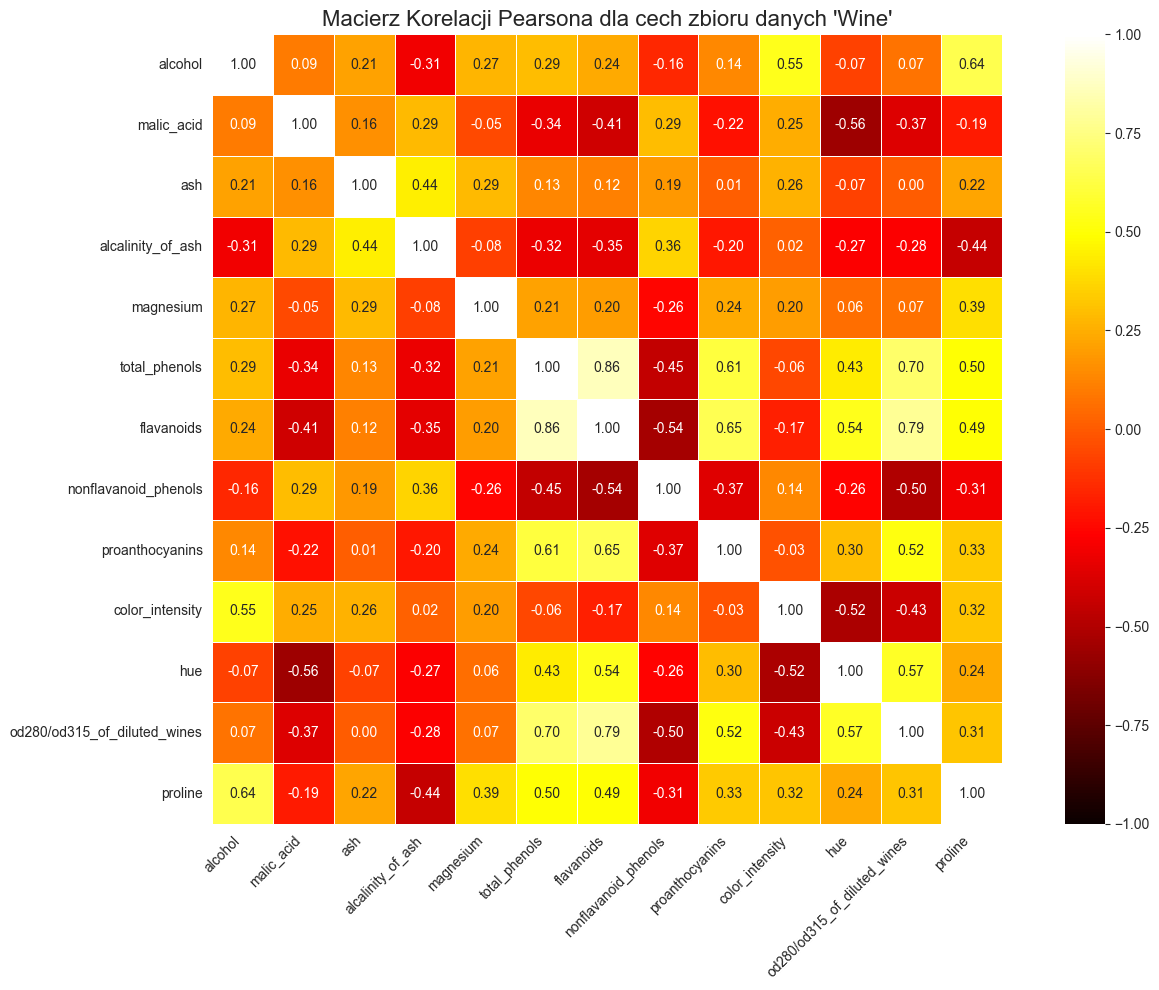

In [71]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap= 'hot',
    vmin=-1, vmax=1,
    linewidths=.5,
    square=True
)

plt.title("Macierz Korelacji Pearsona dla cech zbioru danych 'Wine'", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Korelacja Spearmana

In [72]:
correlation_spearman_matrix = df.corr(method='spearman')

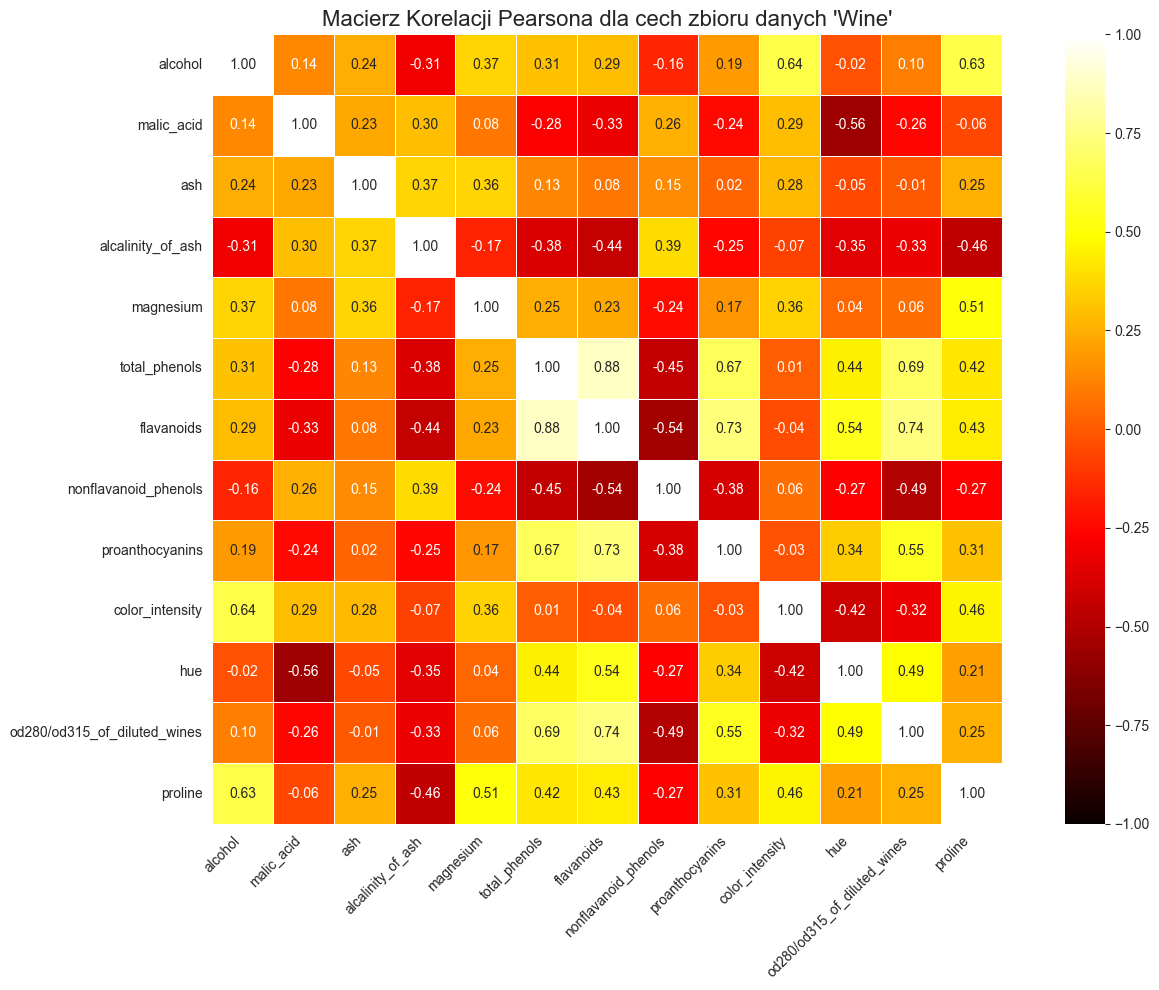

In [73]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap= 'hot',
    vmin=-1, vmax=1,
    linewidths=.5,
    square=True
)

plt.title("Macierz Korelacji Pearsona dla cech zbioru danych 'Wine'", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Korelacja tau Kendalla

In [74]:
correlation_kendall_matrix = df.corr(method="kendall")

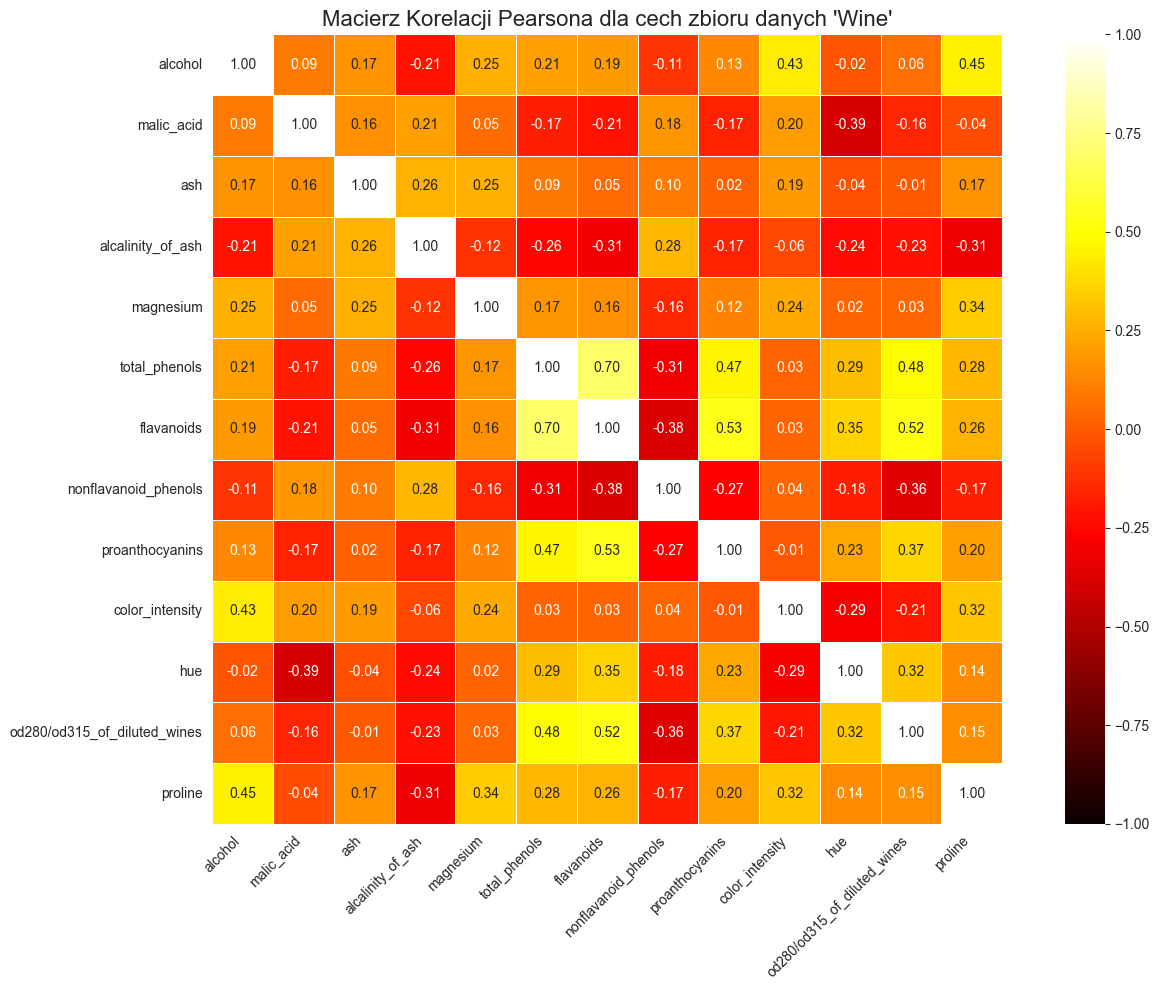

In [75]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_kendall_matrix,
    annot=True,
    fmt=".2f",
    cmap= 'hot',
    vmin=-1, vmax=1,
    linewidths=.5,
    square=True
)

plt.title("Macierz Korelacji Pearsona dla cech zbioru danych 'Wine'", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Różnica międezy korelacją Pearsona i Kendalla oraz Spearmana i Kendalla

In [77]:
p = df.corr(method='pearson').to_numpy()
s = df.corr(method='spearman').to_numpy()
k = df.corr(method='kendall').to_numpy()

diff_ps = p - s
diff_pk = p - k

diff_ps_df = pd.DataFrame(diff_ps, columns=wine.feature_names, index=wine.feature_names)
diff_pk_df = pd.DataFrame(diff_pk, columns=wine.feature_names, index=wine.feature_names)

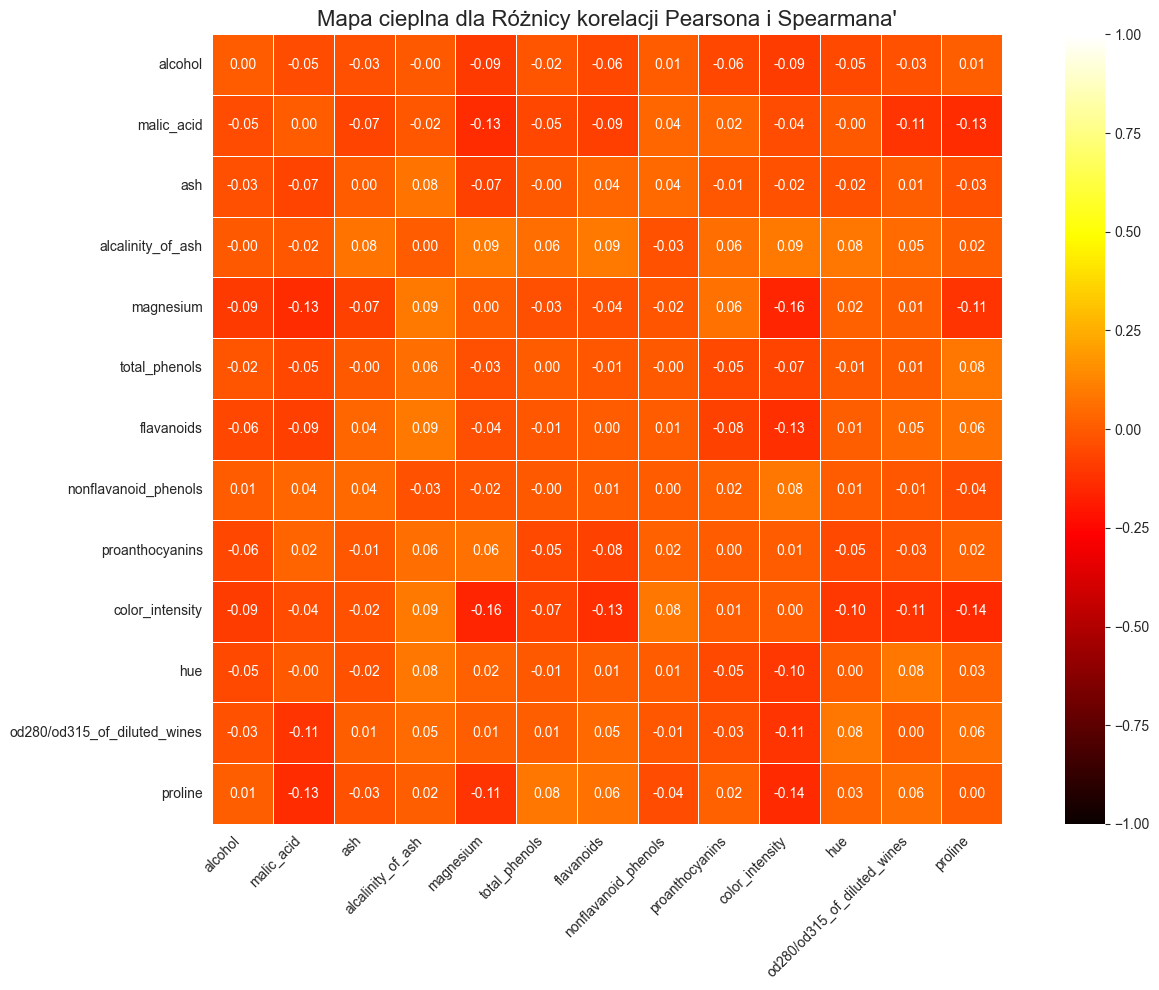

In [78]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    diff_ps_df,
    annot=True,
    fmt=".2f",
    cmap= 'hot',
    vmin=-1, vmax=1,
    linewidths=.5,
    square=True
)

plt.title("Mapa cieplna dla Różnicy korelacji Pearsona i Spearmana'", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

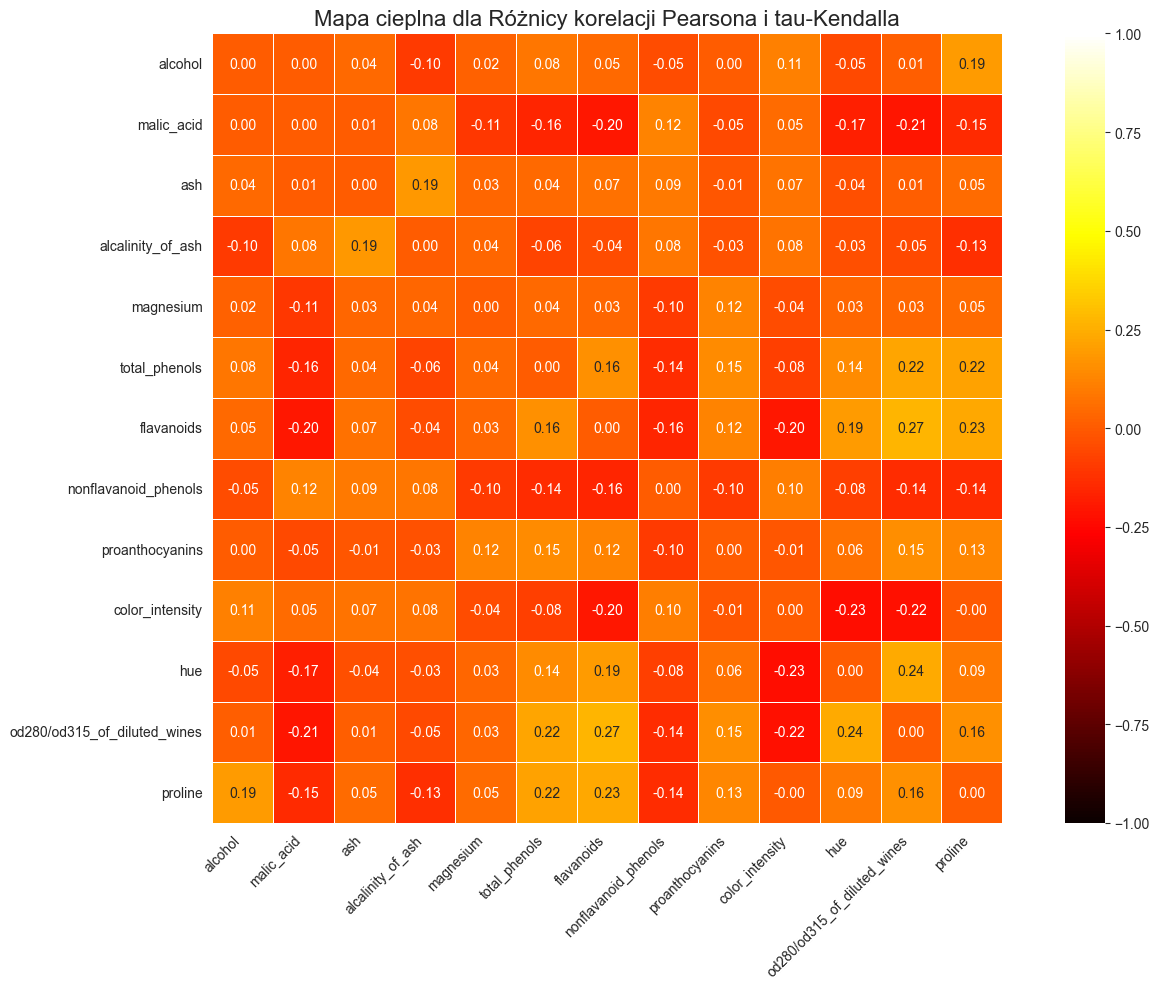

In [79]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    diff_pk_df,
    annot=True,
    fmt=".2f",
    cmap= 'hot',
    vmin=-1, vmax=1,
    linewidths=.5,
    square=True
)

plt.title("Mapa cieplna dla Różnicy korelacji Pearsona i tau-Kendalla", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [80]:
print(non_normal_features)

['alcohol', 'total_phenols', 'flavanoids', 'od280/od315_of_diluted_wines']


Odpowiedź: Tak można stwierdzić, że różnice w korelacji wyliczoną metodą Pearsona w porównaniu z pozostałymi dwoma występują dla cech, które nie wykazuja cech normalności.

## Zadanie 5

In [81]:
df['Class'] = wine.target

spearman_corr = df.corr(method="spearman")['Class'].drop('Class')
sorted_corr = spearman_corr.sort_values(ascending=False)

In [82]:
features_to_drop = spearman_corr.abs().sort_values().head(3).index.tolist()

In [52]:
df_reduced = df.drop(columns=features_to_drop + ['Class'])

In [97]:
accuracy_full = bootstrap_knn(X_train_full, y_train, X_test_full, y_test, n_bootstrap=100)

X_train_red, X_test_red, _, _ = train_test_split(X_red, y, test_size=0.2, random_state=42)
accuracy_red = bootstrap_knn(X_train_red, y_train, X_test_red, y_test, n_bootstrap=100)

In [98]:
print(accuracy_red.mean())
print(accuracy.mean())


0.403611111111111
0.6258055555555555


Usunięcie 3 najmniej skorelowanych cech z nasza cecha decydujaca obniżyło accuracy modelu